In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nowayte","key":"54239b66326321593da59c786dbe3b16"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d uciml/pima-indians-diabetes-database
!unzip -o pima-indians-diabetes-database.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
  0% 0.00/8.91k [00:00<?, ?B/s]
100% 8.91k/8.91k [00:00<00:00, 40.0MB/s]
Archive:  pima-indians-diabetes-database.zip
  inflating: diabetes.csv            


In [4]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print(df.shape)
print(df.info())
display(df.describe())
print("\nClass distribution:")
print(df["Outcome"].value_counts(normalize=True))

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Class distribution:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [6]:
zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_invalid_cols:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [7]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


In [9]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

zero_invalid_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
all_features = X.columns.tolist()

class ZeroToNaNTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].replace(0, np.nan)
        return X

numeric_preprocessor = Pipeline([
    ("zero_to_nan", ZeroToNaNTransformer(columns=zero_invalid_cols)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, all_features)
])

In [10]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

models_and_grids = {
    "logistic_regression": {
        "model": LogisticRegression(max_iter=5000, random_state=42),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10, 100],
            "classifier__solver": ["liblinear", "lbfgs"],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "random_forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__max_depth": [None, 3, 5, 10],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "gradient_boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__learning_rate": [0.01, 0.05, 0.1],
            "classifier__max_depth": [2, 3, 4],
            "classifier__subsample": [0.8, 1.0]
        }
    }
}

In [12]:
from sklearn.pipeline import Pipeline

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

best_models = {}
cv_results_summary = []

for name, cfg in models_and_grids.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", cfg["model"])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=cfg["params"],
        scoring=scoring,
        refit="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid

    cv_results_summary.append({
        "model": name,
        "best_params": grid.best_params_,
        "best_cv_roc_auc": grid.best_score_
    })

cv_summary_df = pd.DataFrame(cv_results_summary)
cv_summary_df.sort_values("best_cv_roc_auc", ascending=False)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits


,model,best_params,best_cv_roc_auc
0,logistic_regression,"{'classifier__C': 0.1, 'classifier__class_weig...",0.844994
1,random_forest,"{'classifier__class_weight': 'balanced', 'clas...",0.841517
2,gradient_boosting,"{'classifier__learning_rate': 0.05, 'classifie...",0.838059


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, fitted_search, X_test, y_test):
    best_model = fitted_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    }

    print(f"\n{name.upper()}")
    print("=" * 60)
    print("Best Params:", fitted_search.best_params_)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return results

In [14]:
test_results = []

for name, fitted_search in best_models.items():
    res = evaluate_model(name, fitted_search, X_test, y_test)
    test_results.append(res)

test_results_df = pd.DataFrame(test_results).sort_values("roc_auc", ascending=False)
test_results_df


LOGISTIC_REGRESSION
Best Params: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.73      0.76       100
           1       0.57      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.71       154

Confusion Matrix:
 [[73 27]
 [18 36]]

RANDOM_FOREST
Best Params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.74      0.80       100
           1       0.62      0.80      0.70        54

    accuracy                           0.76       154
   macro avg       0.75      0.77    

,model,accuracy,precision,recall,f1_score,roc_auc
2,gradient_boosting,0.727273,0.630435,0.537037,0.580000,0.820185
1,random_forest,0.759740,0.623188,0.796296,0.699187,0.817037
0,logistic_regression,0.707792,0.571429,0.666667,0.615385,0.810370


<Figure size 800x600 with 0 Axes>

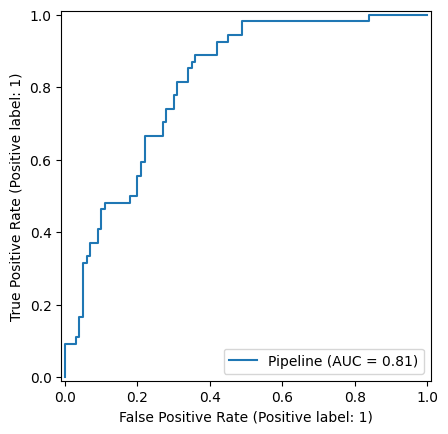

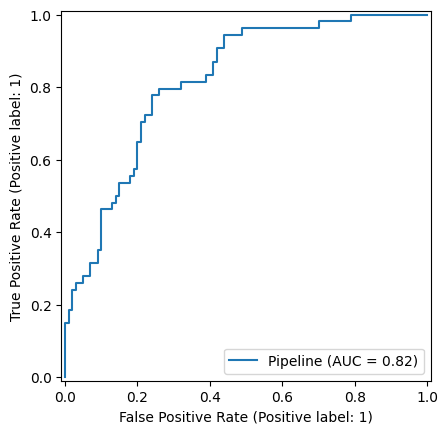

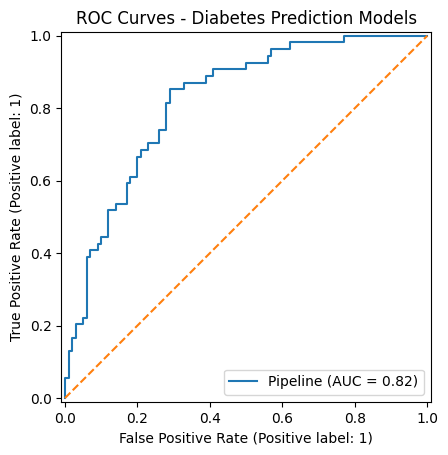

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for name, fitted_search in best_models.items():
    best_model = fitted_search.best_estimator_
    RocCurveDisplay.from_estimator(best_model, X_test, y_test)

plt.title("ROC Curves - Diabetes Prediction Models")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

In [16]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_log_pipe = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

smote_log_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["liblinear", "lbfgs"],
    "classifier__class_weight": [None, "balanced"]
}

smote_search = GridSearchCV(
    estimator=smote_log_pipe,
    param_grid=smote_log_grid,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

smote_search.fit(X_train, y_train)
smote_result = evaluate_model("smote_logistic_regression", smote_search, X_test, y_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

SMOTE_LOGISTIC_REGRESSION
Best Params: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__solver': 'liblinear'}

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154

Confusion Matrix:
 [[74 26]
 [19 35]]


In [17]:
import joblib

best_name = test_results_df.iloc[0]["model"]
best_estimator = best_models[best_name].best_estimator_

joblib.dump(best_estimator, "best_diabetes_model.joblib")
joblib.dump(best_models[best_name], "best_gridsearch_object.joblib")

print("Saved:", best_name)

Saved: gradient_boosting


In [18]:
rf_best = best_models["random_forest"].best_estimator_

In [19]:
rf_model = rf_best.named_steps["classifier"]
rf_preprocessor = rf_best.named_steps["preprocessor"]

In [20]:
X_test_transformed = rf_preprocessor.transform(X_test)

In [22]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

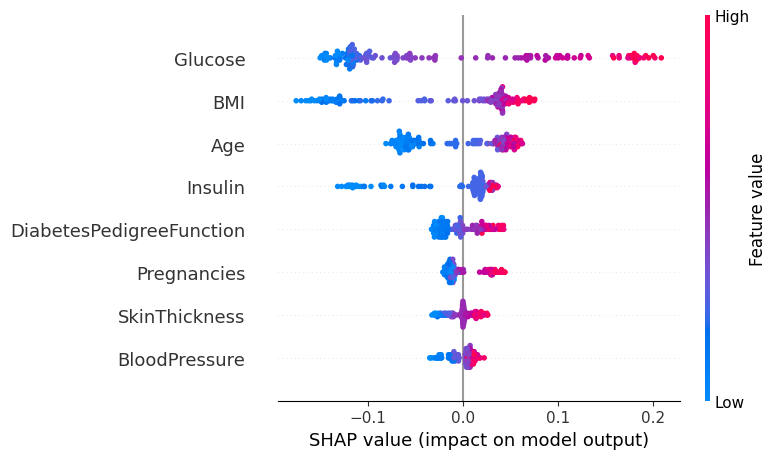

In [24]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=X.columns
)

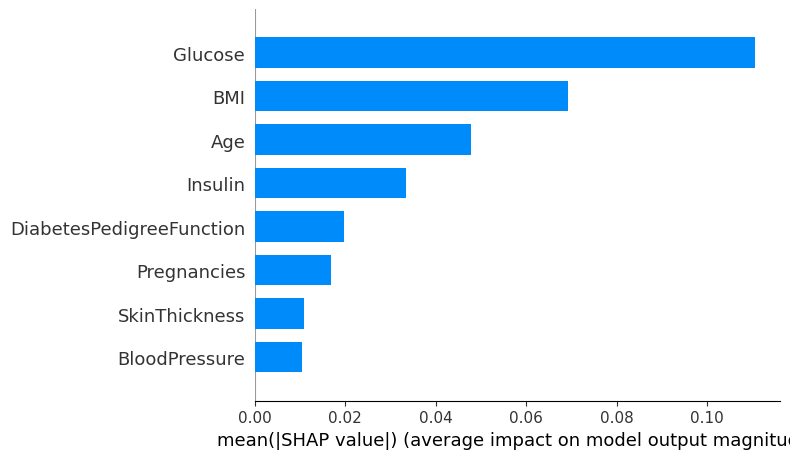

In [26]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=X.columns,
    plot_type="bar"
)

In [27]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    rf_best,
    method="sigmoid",
    cv=5
)

calibrated_rf.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('zero_to_nan',
                                                                                                    ZeroToNaNTransformer(columns=['Glucose',
                                                                                                                                  'BloodPressure',
                                                                                                                                  'SkinThickness',
                                                                                                                                  'Insulin',
                                                                                                                                  'BMI'])),
                                                                                                   ('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['Pregnancies',
                                                                                    'Glucose',
                                                                                    'BloodPressure',
                                                                                    'SkinThickness',
                                                                                    'Insulin',
                                                                                    'BMI',
                                                                                    'DiabetesPedigreeFunction',
                                                                                    'Age'])])),
                                                 ('classifier',
                                                  RandomForestClassifier(class_weight='balanced',
                                                                         max_depth=3,
                                                                         min_samples_leaf=4,
                                                                         min_samples_split=10,
                                                                         n_estimators=200,
                                                                         random_state=42))]))

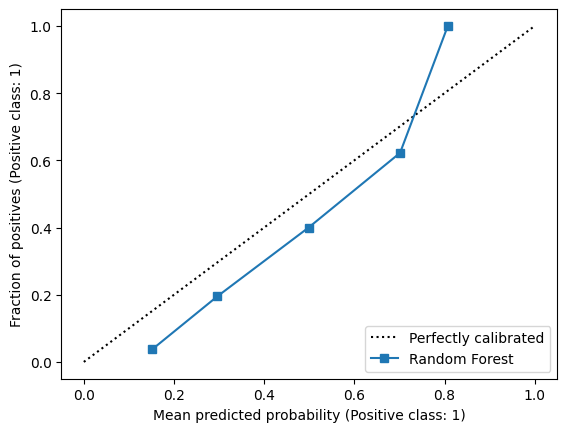

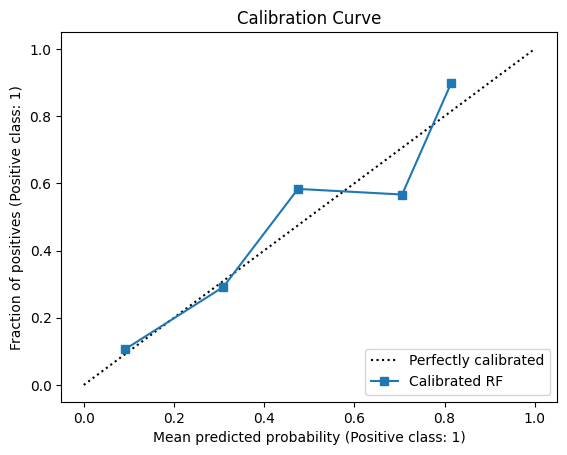

In [28]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    rf_best,
    X_test,
    y_test,
    name="Random Forest"
)

CalibrationDisplay.from_estimator(
    calibrated_rf,
    X_test,
    y_test,
    name="Calibrated RF"
)

plt.title("Calibration Curve")
plt.show()

In [29]:
y_prob = rf_best.predict_proba(X_test)[:,1]

In [30]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1,0.9,0.05)

results = []

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    results.append({
        "threshold": t,
        "precision": precision_score(y_test,y_pred_t),
        "recall": recall_score(y_test,y_pred_t),
        "f1": f1_score(y_test,y_pred_t)
    })

threshold_df = pd.DataFrame(results)
threshold_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,threshold,precision,recall,f1
0,0.10,0.357616,1.000000,0.526829
1,0.15,0.377622,1.000000,0.548223
2,0.20,0.417323,0.981481,0.585635
3,0.25,0.440678,0.962963,0.604651
4,0.30,0.490566,0.962963,0.650000
5,0.35,0.531915,0.925926,0.675676
6,0.40,0.523256,0.833333,0.642857
7,0.45,0.578947,0.814815,0.676923
8,0.50,0.623188,0.796296,0.699187
9,0.55,0.615385,0.592593,0.603774


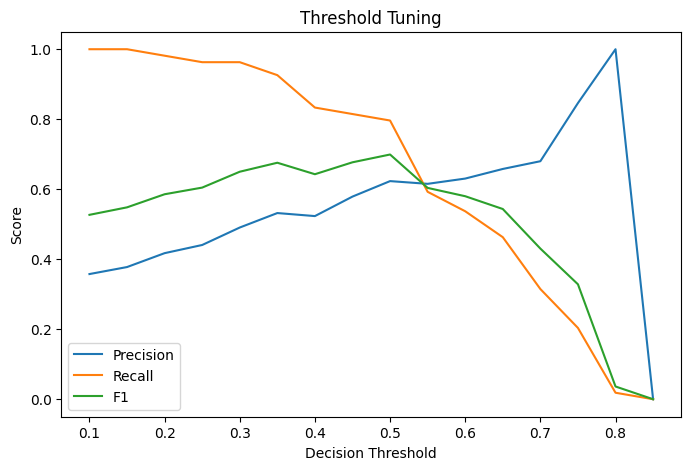

In [31]:
plt.figure(figsize=(8,5))

plt.plot(threshold_df["threshold"],threshold_df["precision"],label="Precision")
plt.plot(threshold_df["threshold"],threshold_df["recall"],label="Recall")
plt.plot(threshold_df["threshold"],threshold_df["f1"],label="F1")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Threshold Tuning")
plt.show()

In [32]:
import joblib

joblib.dump(calibrated_rf,"diabetes_final_model.pkl")

['diabetes_final_model.pkl']

In [33]:
best_final_model = calibrated_rf

In [34]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def bootstrap_metrics(model, X_test, y_test, n_bootstraps=2000, random_state=42):
    rng = np.random.RandomState(random_state)
    y_test = np.array(y_test)

    aucs = []
    accuracies = []
    precisions = []
    recalls = []
    f1s = []

    n = len(y_test)

    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)

        X_sample = X_test.iloc[indices] if hasattr(X_test, "iloc") else X_test[indices]
        y_sample = y_test[indices]

        # skip invalid bootstrap samples with only one class
        if len(np.unique(y_sample)) < 2:
            continue

        y_prob = model.predict_proba(X_sample)[:, 1]
        y_pred = model.predict(X_sample)

        aucs.append(roc_auc_score(y_sample, y_prob))
        accuracies.append(accuracy_score(y_sample, y_pred))
        precisions.append(precision_score(y_sample, y_pred, zero_division=0))
        recalls.append(recall_score(y_sample, y_pred, zero_division=0))
        f1s.append(f1_score(y_sample, y_pred, zero_division=0))

    def summarize(metric_values, name):
        return {
            "metric": name,
            "mean": np.mean(metric_values),
            "lower_95": np.percentile(metric_values, 2.5),
            "upper_95": np.percentile(metric_values, 97.5)
        }

    summary = pd.DataFrame([
        summarize(aucs, "roc_auc"),
        summarize(accuracies, "accuracy"),
        summarize(precisions, "precision"),
        summarize(recalls, "recall"),
        summarize(f1s, "f1_score")
    ])

    return summary

In [36]:
best_final_model = calibrated_rf  # or rf_best if you want the uncalibrated one

bootstrap_summary = bootstrap_metrics(best_final_model, X_test, y_test, n_bootstraps=2000)
bootstrap_summary

,metric,mean,lower_95,upper_95
0,roc_auc,0.810852,0.732588,0.876484
1,accuracy,0.720756,0.642857,0.792208
2,precision,0.616218,0.473660,0.755556
3,recall,0.534674,0.400000,0.666818
4,f1_score,0.570054,0.449986,0.683344


In [37]:
for _, row in bootstrap_summary.iterrows():
    print(
        f"{row['metric']}: "
        f"{row['mean']:.3f} "
        f"(95% CI {row['lower_95']:.3f} - {row['upper_95']:.3f})"
    )

roc_auc: 0.811 (95% CI 0.733 - 0.876)
accuracy: 0.721 (95% CI 0.643 - 0.792)
precision: 0.616 (95% CI 0.474 - 0.756)
recall: 0.535 (95% CI 0.400 - 0.667)
f1_score: 0.570 (95% CI 0.450 - 0.683)


In [38]:
rf_best_params = best_models["random_forest"].best_params_
rf_best_params

{'classifier__class_weight': 'balanced',
 'classifier__max_depth': 3,
 'classifier__min_samples_leaf': 4,
 'classifier__min_samples_split': 10,
 'classifier__n_estimators': 200}

In [39]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_feature_importances = []

# Extract classifier params only
rf_params = {
    k.replace("classifier__", ""): v
    for k, v in best_models["random_forest"].best_params_.items()
}

for fold_idx, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_valid = X_train.iloc[valid_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    fold_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42, **rf_params))
    ])

    fold_pipeline.fit(X_fold_train, y_fold_train)

    fold_model = fold_pipeline.named_steps["classifier"]
    importances = fold_model.feature_importances_

    rf_feature_importances.append(importances)

rf_feature_importances = np.array(rf_feature_importances)

feature_stability_df = pd.DataFrame({
    "feature": X.columns,
    "mean_importance": rf_feature_importances.mean(axis=0),
    "std_importance": rf_feature_importances.std(axis=0)
}).sort_values("mean_importance", ascending=False)

feature_stability_df

,feature,mean_importance,std_importance
1,Glucose,0.378142,0.017493
5,BMI,0.187381,0.009022
7,Age,0.128563,0.010884
4,Insulin,0.114991,0.005329
6,DiabetesPedigreeFunction,0.054556,0.007735
3,SkinThickness,0.052281,0.012625
0,Pregnancies,0.047065,0.006275
2,BloodPressure,0.037021,0.006507


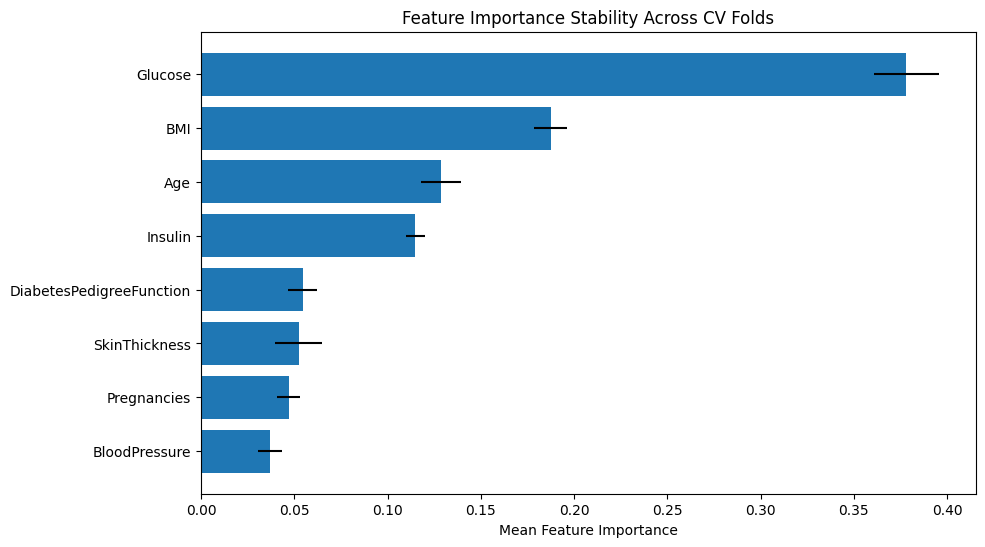

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    feature_stability_df["feature"],
    feature_stability_df["mean_importance"],
    xerr=feature_stability_df["std_importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Mean Feature Importance")
plt.title("Feature Importance Stability Across CV Folds")
plt.show()

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def decision_curve_analysis(y_true, y_prob, thresholds=np.arange(0.01, 0.99, 0.01)):
    y_true = np.array(y_true)
    N = len(y_true)

    net_benefits_model = []
    net_benefits_all = []
    net_benefits_none = []

    prevalence = y_true.mean()

    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)

        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))

        nb_model = (TP / N) - (FP / N) * (pt / (1 - pt))
        nb_all = prevalence - (1 - prevalence) * (pt / (1 - pt))
        nb_none = 0.0

        net_benefits_model.append(nb_model)
        net_benefits_all.append(nb_all)
        net_benefits_none.append(nb_none)

    return pd.DataFrame({
        "threshold": thresholds,
        "model": net_benefits_model,
        "treat_all": net_benefits_all,
        "treat_none": net_benefits_none
    })

In [42]:
y_prob_final = best_final_model.predict_proba(X_test)[:, 1]

dca_df = decision_curve_analysis(y_test, y_prob_final)
dca_df.head()

,threshold,model,treat_all,treat_none
0,0.01,0.344090,0.344090,0.0
1,0.02,0.337397,0.337397,0.0
2,0.03,0.330767,0.330566,0.0
3,0.04,0.324675,0.323593,0.0
4,0.05,0.321941,0.316473,0.0


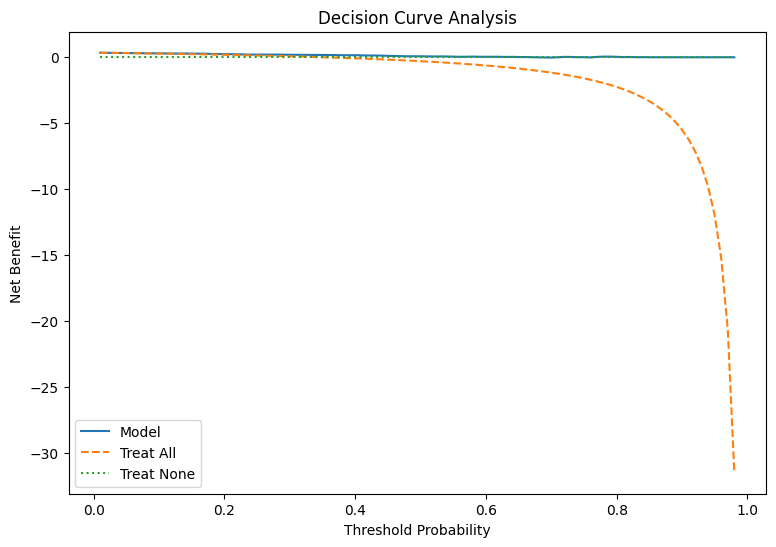

In [43]:
plt.figure(figsize=(9, 6))
plt.plot(dca_df["threshold"], dca_df["model"], label="Model")
plt.plot(dca_df["threshold"], dca_df["treat_all"], label="Treat All", linestyle="--")
plt.plot(dca_df["threshold"], dca_df["treat_none"], label="Treat None", linestyle=":")
plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("Decision Curve Analysis")
plt.legend()
plt.show()

In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score, confusion_matrix

thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "f2": fbeta_score(y_test, y_pred_t, beta=2, zero_division=0),
        "specificity": tn / (tn + fp),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,precision,recall,f1,f2,specificity,tp,fp,tn,fn
0,0.10,0.456140,0.962963,0.619048,0.787879,0.38,52,62,38,2
1,0.15,0.531250,0.944444,0.680000,0.817308,0.55,51,45,55,3
2,0.20,0.534091,0.870370,0.661972,0.773026,0.59,47,41,59,7
3,0.25,0.536585,0.814815,0.647059,0.738255,0.62,44,38,62,10
4,0.30,0.573333,0.796296,0.666667,0.738832,0.68,43,32,68,11
5,0.35,0.589041,0.796296,0.677165,0.743945,0.70,43,30,70,11
6,0.40,0.625000,0.740741,0.677966,0.714286,0.76,40,24,76,14
7,0.45,0.622642,0.611111,0.616822,0.613383,0.80,33,20,80,21
8,0.50,0.617021,0.537037,0.574257,0.551331,0.82,29,18,82,25
9,0.55,0.622222,0.518519,0.565657,0.536398,0.83,28,17,83,26


In [45]:
best_threshold_row = threshold_results_df.sort_values("f2", ascending=False).iloc[0]
best_threshold_row

,1
threshold,0.150000
precision,0.531250
recall,0.944444
f1,0.680000
f2,0.817308
specificity,0.550000
tp,51.000000
fp,45.000000
tn,55.000000
fn,3.000000


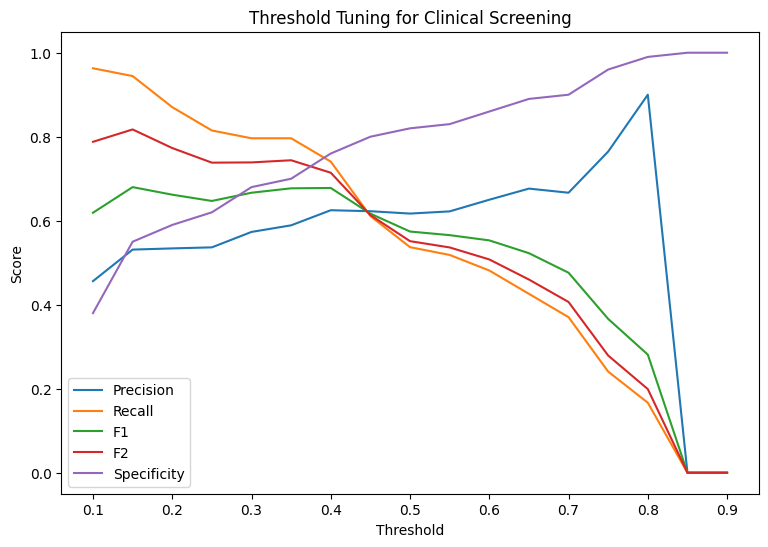

In [46]:
plt.figure(figsize=(9, 6))
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1"], label="F1")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f2"], label="F2")
plt.plot(threshold_results_df["threshold"], threshold_results_df["specificity"], label="Specificity")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for Clinical Screening")
plt.legend()
plt.show()